# Week 1 · Lecture 1 — Bayes' Theorem from First Principles

## Learning objectives

By the end of this notebook you will be able to:

1. Derive Bayes' theorem from the axioms of probability without appealing to memory.
2. Identify the four canonical quantities in any Bayesian update — **prior**, **likelihood**, **evidence**, **posterior** — in both discrete and continuous models.
3. Compute a posterior exactly for a discrete hypothesis space by enumeration.
4. Compute a posterior in closed form for a continuous parameter using a conjugate prior (Beta–Binomial).
5. Draw and interpret the *posterior predictive* distribution and explain why it differs from the plug-in predictive at $\hat{\theta}_{\text{MAP}}$.

## 1. From the product rule to Bayes' theorem

Starting from the **product rule** of probability,

$$
P(A, B) = P(A \mid B)\, P(B) = P(B \mid A)\, P(A),
$$

we equate the two factorisations and divide by $P(B)$ (assuming $P(B) > 0$):

$$
\boxed{\,P(A \mid B) \;=\; \frac{P(B \mid A)\, P(A)}{P(B)}\,}
$$

There is nothing more to "Bayes' theorem" than this re-arrangement. The Bayesian content is in how we *interpret* the symbols: $A$ is taken to be an unobserved quantity of interest (a parameter $\theta$ or a hypothesis $\mathcal{H}$), $B$ is observed data $\mathcal{D}$, and we read

$$
\underbrace{p(\theta \mid \mathcal{D})}_{\text{posterior}} \;=\; \frac{\overbrace{p(\mathcal{D} \mid \theta)}^{\text{likelihood}}\;\overbrace{p(\theta)}^{\text{prior}}}{\underbrace{p(\mathcal{D})}_{\text{evidence}}}.
$$

The **evidence** (or *marginal likelihood*) is the normalising constant

$$
p(\mathcal{D}) \;=\; \int p(\mathcal{D} \mid \theta)\, p(\theta)\, d\theta,
$$

(or a sum, in the discrete case). Almost the entire technical apparatus of computational Bayesian inference — MCMC, variational methods, Laplace approximations — exists because this integral is usually intractable.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(0)
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 2. A discrete example: which coin?

Three coins sit on a table. Their probabilities of heads are $\theta \in \{0.25,\ 0.5,\ 0.75\}$ — call them *biased-tails*, *fair*, and *biased-heads*. A friend picks one at random (uniformly) and tosses it $N=20$ times, reporting $k=15$ heads. Which coin did they pick?

The hypothesis space is the three-element set $\Theta = \{0.25, 0.5, 0.75\}$. The prior is uniform:

$$
p(\theta = 0.25) = p(\theta = 0.5) = p(\theta = 0.75) = \tfrac{1}{3}.
$$

The likelihood is binomial:

$$
p(\mathcal{D} \mid \theta) \;=\; \binom{N}{k}\, \theta^{k} (1-\theta)^{N-k}.
$$

The binomial coefficient cancels when we normalise across $\Theta$, but we keep it for numerical clarity.


In [2]:
theta_grid = np.array([0.25, 0.5, 0.75])
prior      = np.array([1/3, 1/3, 1/3])

N, k = 20, 15
likelihood = stats.binom.pmf(k, N, theta_grid)

unnorm     = likelihood * prior
evidence   = unnorm.sum()
posterior  = unnorm / evidence

for t, pr, lk, po in zip(theta_grid, prior, likelihood, posterior):
    print(f"theta={t:.2f}  prior={pr:.4f}  likelihood={lk:.4e}  posterior={po:.4f}")

print(f"\nEvidence p(D) = {evidence:.4e}")


theta=0.25  prior=0.3333  likelihood=3.4265e-06  posterior=0.0000
theta=0.50  prior=0.3333  likelihood=1.4786e-02  posterior=0.0681
theta=0.75  prior=0.3333  likelihood=2.0233e-01  posterior=0.9319

Evidence p(D) = 7.2373e-02


The posterior concentrates on $\theta = 0.75$. Notice that we never had to *do* anything but evaluate the likelihood at three points, multiply by the prior, and normalise. This is the entire Bayesian workflow in microcosm.

### Visualising the update


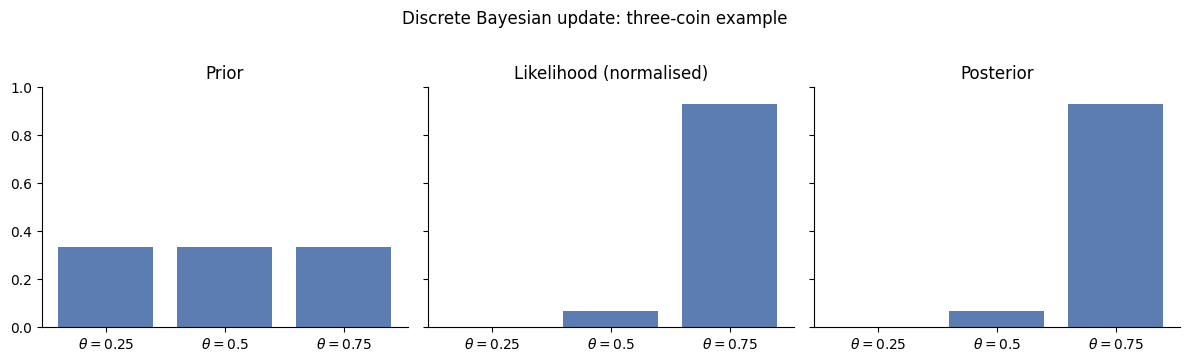

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
labels = [r"$\theta=0.25$", r"$\theta=0.5$", r"$\theta=0.75$"]

for ax, vals, title in zip(
    axes,
    [prior, likelihood / likelihood.sum(), posterior],
    ["Prior", "Likelihood (normalised)", "Posterior"],
):
    ax.bar(labels, vals, color=["#5B7DB1", "#5B7DB1", "#5B7DB1"])
    ax.set_title(title)
    ax.set_ylim(0, 1)

fig.suptitle("Discrete Bayesian update: three-coin example", y=1.02)
plt.tight_layout()
plt.show()


## 3. A continuous example: the Beta–Binomial conjugate pair

Now let $\theta \in [0, 1]$ be a *continuous* parameter — the probability of heads of a single biased coin. We need a prior on $[0, 1]$. The Beta distribution

$$
p(\theta) \;=\; \mathrm{Beta}(\theta \mid \alpha, \beta) \;=\; \frac{\theta^{\alpha - 1}(1-\theta)^{\beta - 1}}{B(\alpha, \beta)}
$$

is the canonical choice, because it is **conjugate** to the binomial likelihood: posterior and prior live in the same family, with updated hyperparameters. We will derive that property below.

### 3.1 Conjugacy by inspection

Given $k$ heads out of $N$ trials,

$$
p(\theta \mid \mathcal{D}) \;\propto\; \underbrace{\theta^{k}(1-\theta)^{N-k}}_{\text{likelihood}} \cdot \underbrace{\theta^{\alpha-1}(1-\theta)^{\beta-1}}_{\text{prior}} \;=\; \theta^{\alpha + k - 1}(1-\theta)^{\beta + N - k - 1}.
$$

The right-hand side is the kernel of a Beta distribution with updated parameters $\alpha' = \alpha + k$, $\beta' = \beta + N - k$. Therefore

$$
\boxed{\,\theta \mid \mathcal{D} \;\sim\; \mathrm{Beta}\!\left(\alpha + k,\ \beta + N - k\right).}
$$

The normalising constant comes for free from the Beta density. **This is the whole point of conjugate priors**: the posterior is available in closed form without computing any integral.


In [4]:
def beta_binomial_update(alpha, beta, k, N):
    # Posterior Beta parameters after observing k successes in N trials
    return alpha + k, beta + N - k


# Start with a weakly informative prior centred on 0.5
alpha0, beta0 = 2.0, 2.0
N_total, k_total = 20, 15
alpha_post, beta_post = beta_binomial_update(alpha0, beta0, k_total, N_total)
print(f"Posterior: Beta({alpha_post:.1f}, {beta_post:.1f})")
print(f"Posterior mean = {alpha_post / (alpha_post + beta_post):.4f}")
print(f"MLE estimate   = {k_total / N_total:.4f}")


Posterior: Beta(17.0, 7.0)
Posterior mean = 0.7083
MLE estimate   = 0.7500


The posterior mean and the MLE are close but not identical: the prior pulls the estimate toward $0.5$. As $N \to \infty$, the prior's influence vanishes — a manifestation of the **Bernstein–von Mises theorem**, which says the posterior concentrates around the MLE at rate $\sqrt{N}$ under regularity conditions.

### 3.2 Sequential updating

A second beauty of conjugate updating: the posterior after observing $\mathcal{D}_1$ can be used as the *prior* for $\mathcal{D}_2$, and the resulting posterior is identical to the one we would have obtained by treating $\mathcal{D}_1 \cup \mathcal{D}_2$ as a single batch. Let us verify this empirically.


In [5]:
# Simulate 20 sequential coin tosses with true theta = 0.7
true_theta = 0.7
N_trials = 20
flips = stats.bernoulli.rvs(true_theta, size=N_trials, random_state=42)
print(f"Observed flips: {flips}")

# Sequentially update the Beta prior
alpha, beta = 2.0, 2.0  # initial prior
trace = [(alpha, beta)]
for flip in flips:
    alpha, beta = beta_binomial_update(alpha, beta, k=flip, N=1)
    trace.append((alpha, beta))

# Check: same as batch update?
alpha_batch, beta_batch = beta_binomial_update(2.0, 2.0, k=flips.sum(), N=N_trials)
print(f"\nSequential final: Beta({alpha:.1f}, {beta:.1f})")
print(f"Batch final     : Beta({alpha_batch:.1f}, {beta_batch:.1f})")


Observed flips: [1 0 0 1 1 1 1 0 1 0 1 0 0 1 1 1 1 1 1 1]

Sequential final: Beta(16.0, 8.0)
Batch final     : Beta(16.0, 8.0)


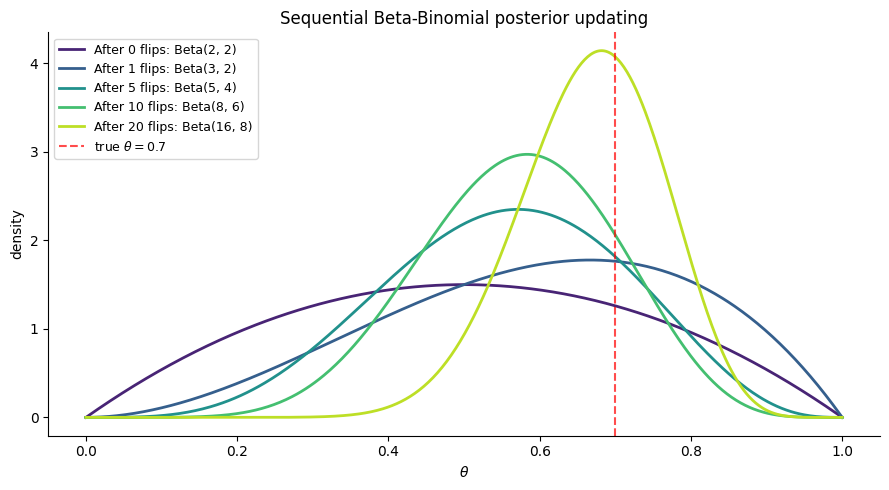

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
theta_plot = np.linspace(0, 1, 500)

# Show every 5th step for clarity
steps_to_show = [0, 1, 5, 10, 20]
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(steps_to_show)))

for i, step in enumerate(steps_to_show):
    a, b = trace[step]
    ax.plot(theta_plot, stats.beta.pdf(theta_plot, a, b),
            color=colors[i], lw=2, label=f"After {step} flips: Beta({a:.0f}, {b:.0f})")

ax.axvline(true_theta, color="red", ls="--", alpha=0.7, label=fr"true $\theta={true_theta}$")
ax.set_xlabel(r"$\theta$")
ax.set_ylabel("density")
ax.set_title("Sequential Beta-Binomial posterior updating")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()


The posterior concentrates around the true value and narrows as evidence accumulates — exactly what a coherent probabilistic update should do.

## 4. The posterior predictive distribution

A frequent mistake is to summarise the posterior by a single point (e.g.\ the MAP) and use the plug-in prediction $p(x_{\text{new}} \mid \hat{\theta}_{\text{MAP}})$. The Bayesian quantity is the **posterior predictive**:

$$
p(x_{\text{new}} \mid \mathcal{D}) \;=\; \int p(x_{\text{new}} \mid \theta)\, p(\theta \mid \mathcal{D})\, d\theta.
$$

This *averages* over parameter uncertainty. For the Beta–Binomial model, the posterior predictive of the next single flip is

$$
p(x_{\text{new}} = 1 \mid \mathcal{D}) \;=\; \int_0^1 \theta \cdot \mathrm{Beta}(\theta \mid \alpha', \beta')\, d\theta \;=\; \frac{\alpha'}{\alpha' + \beta'},
$$

i.e.\ the **posterior mean**. For $M$ future flips, the posterior predictive is the *Beta-binomial* distribution

$$
p(k_{\text{new}} \mid \mathcal{D}) \;=\; \binom{M}{k_{\text{new}}} \frac{B(\alpha' + k_{\text{new}},\ \beta' + M - k_{\text{new}})}{B(\alpha', \beta')}.
$$

Below we compare the plug-in predictive (using $\hat{\theta}_{\text{MAP}}$) against the full posterior predictive.


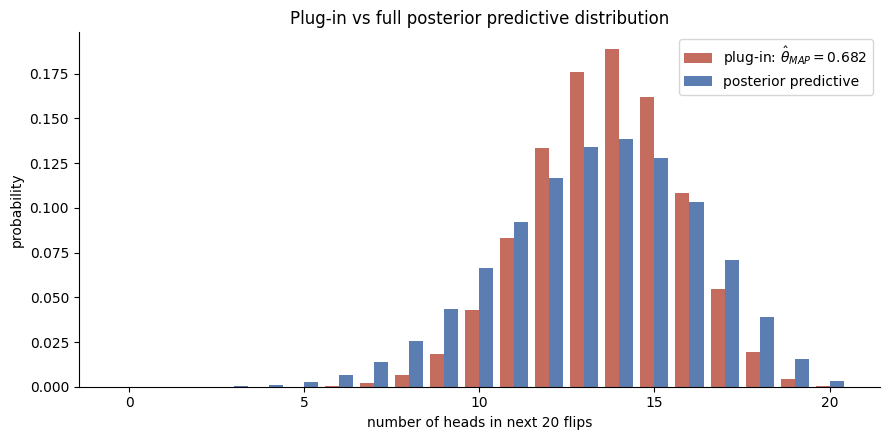

In [7]:
alpha_p, beta_p = alpha, beta              # final posterior parameters
theta_map = (alpha_p - 1) / (alpha_p + beta_p - 2) if alpha_p > 1 and beta_p > 1 else alpha_p / (alpha_p + beta_p)

M = 20
k_grid = np.arange(M + 1)

# Plug-in predictive: Binomial(M, theta_MAP)
plugin = stats.binom.pmf(k_grid, M, theta_map)

# Posterior predictive: Beta-Binomial
posterior_pred = stats.betabinom.pmf(k_grid, M, alpha_p, beta_p)

fig, ax = plt.subplots(figsize=(9, 4.5))
w = 0.4
ax.bar(k_grid - w/2, plugin, width=w, label=fr"plug-in: $\hat\theta_{{MAP}}={theta_map:.3f}$", color="#C46D5E")
ax.bar(k_grid + w/2, posterior_pred, width=w, label="posterior predictive", color="#5B7DB1")
ax.set_xlabel(rf"number of heads in next {M} flips")
ax.set_ylabel("probability")
ax.set_title("Plug-in vs full posterior predictive distribution")
ax.legend()
plt.tight_layout()
plt.show()


The posterior predictive is **wider**: it incorporates uncertainty about $\theta$ in addition to the inherent randomness of the coin. The plug-in predictive ignores the first source of uncertainty and is therefore systematically over-confident — a failure mode that matters enormously in safety-critical applications.

## 5. Exercises

**Exercise 1.1 (Analytical).** Derive Bayes' theorem starting from the *sum rule* and *product rule* only. Show that the evidence $p(\mathcal{D})$ is the only quantity in the posterior that depends on $\mathcal{D}$ alone (i.e.\ does not depend on $\theta$).

**Exercise 1.2 (Computational).** Repeat the three-coin discrete experiment, but vary $k$ from 0 to 20 while keeping $N=20$ fixed. Plot the posterior probability of each coin as a function of $k$. At what value of $k$ does the posterior shift from favouring the fair coin to favouring the biased-heads coin?

**Exercise 1.3 (Conjugacy).** The Gaussian distribution with known variance is self-conjugate under a Gaussian prior on its mean. Show this analytically and verify computationally: simulate $N=50$ observations from $\mathcal{N}(\mu=2,\ \sigma^2=1)$, place a $\mathcal{N}(0, 4)$ prior on $\mu$, and plot the posterior. Confirm the closed-form update against a fine grid evaluation.

**Exercise 1.4 (Posterior predictive).** For the Beta-Binomial of Section 4, plot the *log score* $\log p(k_{\text{new}} \mid \mathcal{D})$ under the plug-in and full posterior predictive, where $k_{\text{new}}$ is generated from the true model with $\theta = 0.7$. Average over 1000 simulations. Which predictive scores better, and by how much?
